# Visualization and Final Analysis

This notebook is used to explore, visualize, and interpret the final dataset in order to better understand its structure, distributions, and patterns. It applies exploratory data analysis techniques such as distribution plots and boxplots to identify trends, variability, and outliers, and uses these visualizations to support clear and interpretable conclusions. In addition, a Spark ML model is analyzed by examining its predictions, probabilities, and coefficients to understand how different features influence the results.

### Importing libraries, loading the final dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# setting some values for plots
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("../data/final_analysis_dataset.csv")
df.head()

,video_id,comment_count,sentiment_mean,sentiment_median,sentiment_std,positive_ratio,negative_ratio,rating,revenue,success
0,-GQjm4TrQIM,40,0.167910,0.0000,0.369336,0.450000,0.125000,6.2,77.04,0
1,-gD-ywBXQns,1,-0.585900,-0.5859,NaN,0.000000,1.000000,6.0,27.36,0
2,0A5rvlALfBk,2,0.000000,0.0000,0.000000,0.000000,0.000000,6.1,47.95,0
3,17Mj1VQBvss,45,0.164442,0.0000,0.410126,0.444444,0.177778,7.4,486.29,0
4,1FuH-Oc6N-w,19,0.106121,0.0000,0.376690,0.315789,0.210526,6.4,55.12,0


### Checking the data

In [3]:
df.shape, df.columns, df.dtypes

((238, 10),
 Index(['video_id', 'comment_count', 'sentiment_mean', 'sentiment_median', 'sentiment_std', 'positive_ratio',
        'negative_ratio', 'rating', 'revenue', 'success'],
       dtype='object'),
 video_id             object
 comment_count         int64
 sentiment_mean      float64
 sentiment_median    float64
 sentiment_std       float64
 positive_ratio      float64
 negative_ratio      float64
 rating              float64
 revenue             float64
 success               int64
 dtype: object)

## EDA

In [4]:
df.isna().sum().sort_values(ascending=False)

sentiment_std       11
video_id             0
comment_count        0
sentiment_mean       0
sentiment_median     0
positive_ratio       0
negative_ratio       0
rating               0
revenue              0
success              0
dtype: int64

In [5]:
# Fixing NaN values
df["sentiment_std"] = df["sentiment_std"].fillna(0)
df.isna().sum().sort_values(ascending=False)

video_id            0
comment_count       0
sentiment_mean      0
sentiment_median    0
sentiment_std       0
positive_ratio      0
negative_ratio      0
rating              0
revenue             0
success             0
dtype: int64

In [6]:
df.describe(include="all")

,video_id,comment_count,sentiment_mean,sentiment_median,sentiment_std,positive_ratio,negative_ratio,rating,revenue,success
count,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
unique,238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,-GQjm4TrQIM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,30.529412,0.139470,0.103577,0.384387,0.441801,0.178661,6.684874,117.913529,0.138655
std,NaN,34.834103,0.177341,0.198154,0.139539,0.196485,0.170817,0.813975,147.403826,0.346315
min,NaN,1.000000,-0.831600,-0.831600,0.000000,0.000000,0.000000,4.300000,0.010000,0.000000
25%,NaN,7.000000,0.056950,0.000000,0.347607,0.333333,0.077782,6.200000,20.750000,0.000000
50%,NaN,14.500000,0.155117,0.000000,0.413897,0.453655,0.150000,6.700000,56.335000,0.000000
75%,NaN,40.750000,0.237400,0.227575,0.460928,0.555556,0.253676,7.300000,128.340000,0.000000


In [7]:
df["success"].value_counts(dropna=False)

success
0    205
1     33
Name: count, dtype: int64

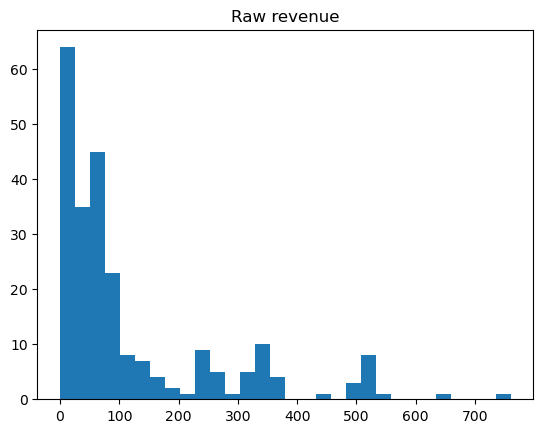

In [8]:
plt.figure()
plt.hist(df["revenue"], bins=30)
plt.title("Raw revenue")
plt.show()


#### Revenue values are not symmetrical and that can affect the evaluation

In [9]:
df["net_sentiment_ratio"] = df["positive_ratio"] - df["negative_ratio"]

# revenue is very skewed, so log helps for plots
df["log_revenue"] = np.log1p(df["revenue"])

df[["positive_ratio","negative_ratio","net_sentiment_ratio","revenue","log_revenue"]].head()

,positive_ratio,negative_ratio,net_sentiment_ratio,revenue,log_revenue
0,0.450000,0.125000,0.325000,77.04,4.357222
1,0.000000,1.000000,-1.000000,27.36,3.344980
2,0.000000,0.000000,0.000000,47.95,3.890799
3,0.444444,0.177778,0.266667,486.29,6.188859
4,0.315789,0.210526,0.105263,55.12,4.027492


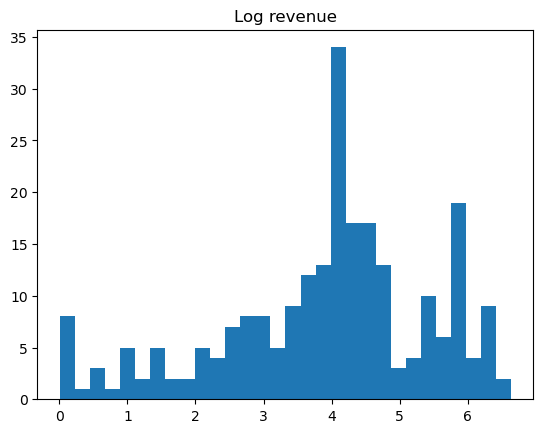

In [10]:
plt.figure()
plt.hist(df["log_revenue"], bins=30)
plt.title("Log revenue")
plt.show()

### Sentiment mean by success

The boxplot shows that there are a more negative sentiments at unsuccessful movies.
The vast majority, successful or not, is located around 0.1 meaning there isn't a clear tendency

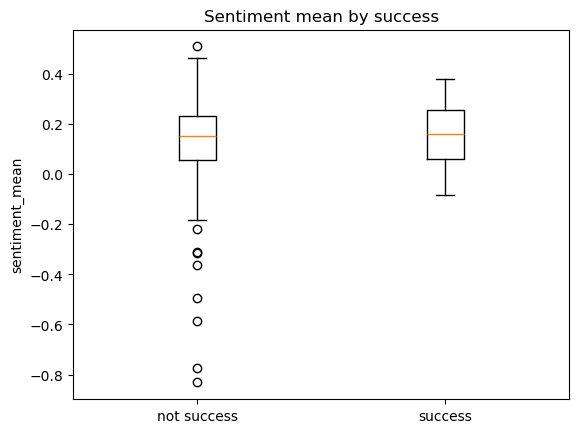

In [11]:
success_0 = df[df["success"] == 0]["sentiment_mean"]
success_1 = df[df["success"] == 1]["sentiment_mean"]

plt.figure()
plt.boxplot([success_0, success_1], labels=["not success", "success"])
plt.title("Sentiment mean by success")
plt.ylabel("sentiment_mean")
plt.show()

### Positive-Negative Ratio

Unsuccessful movies are a little more scattered than successful ones.
That effect might be due to the fact that there are far more movies marked as not-successful than successful.

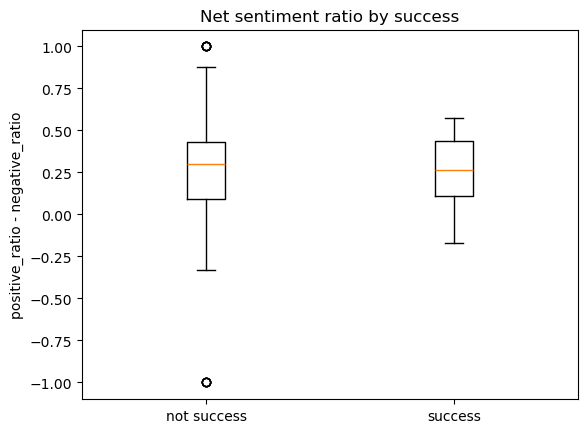

In [12]:
s0 = df[df["success"] == 0]["net_sentiment_ratio"]
s1 = df[df["success"] == 1]["net_sentiment_ratio"]

plt.figure()
plt.boxplot([s0, s1], labels=["not success", "success"])
plt.title("Net sentiment ratio by success")
plt.ylabel("positive_ratio - negative_ratio")
plt.show()


### Is Sentiment biased by comment volume?

Below we wanted to figure out if more comments tend to a better sentiment.
As one can see in the plot below this is not the case.
Successful and unsuccessful movies are both scattered from none to over 100 comments.

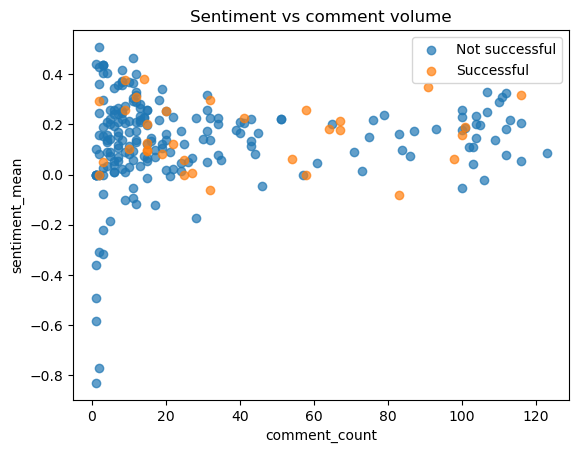

In [13]:
plt.figure()

# not successful
df0 = df[df["success"] == 0]
plt.scatter(
    df0["comment_count"],
    df0["sentiment_mean"],
    label="Not successful",
    alpha=0.7
)

# successful
df1 = df[df["success"] == 1]
plt.scatter(
    df1["comment_count"],
    df1["sentiment_mean"],
    label="Successful",
    alpha=0.7
)

plt.xlabel("comment_count")
plt.ylabel("sentiment_mean")
plt.title("Sentiment vs comment volume")
plt.legend()
plt.show()


### Does a better sentiment lead to higher revenue?

As the plot below shows, there is no correlation between the sentiment and revenue from a movie

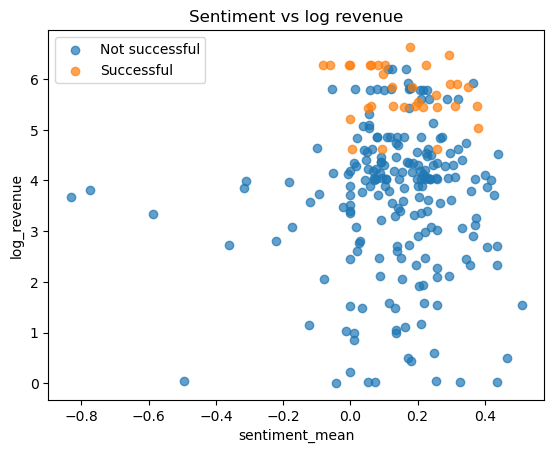

In [14]:
plt.figure()

# not successful
df0 = df[df["success"] == 0]
plt.scatter(
    df0["sentiment_mean"],
    df0["log_revenue"],
    label="Not successful",
    alpha=0.7
)

# successful
df1 = df[df["success"] == 1]
plt.scatter(
    df1["sentiment_mean"],
    df1["log_revenue"],
    label="Successful",
    alpha=0.7
)

plt.xlabel("sentiment_mean")
plt.ylabel("log_revenue")
plt.title("Sentiment vs log revenue")
plt.legend()
plt.show()


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

features = [
    "comment_count",
    "sentiment_mean",
    "sentiment_std",
    "positive_ratio",
    "negative_ratio",
]

X = df[features]
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.87      1.00      0.93        52
           1       0.00      0.00      0.00         8

    accuracy                           0.87        60
   macro avg       0.43      0.50      0.46        60
weighted avg       0.75      0.87      0.80        60

ROC AUC: 0.5504807692307692


In [16]:
coef = pd.Series(
    pipe.named_steps["clf"].coef_[0],
    index=features
).sort_values()

coef


positive_ratio   -0.566065
negative_ratio    0.032825
sentiment_std     0.224625
comment_count     0.268124
sentiment_mean    0.405799
dtype: float64

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

features = [
    "rating",
    "revenue"
]

X = df[features]
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.93      0.98      0.95        52
           1       0.80      0.50      0.62         8

    accuracy                           0.92        60
   macro avg       0.86      0.74      0.78        60
weighted avg       0.91      0.92      0.91        60

ROC AUC: 0.9903846153846154


In [18]:
coef = pd.Series(
    pipe.named_steps["clf"].coef_[0],
    index=features
).sort_values()

coef


revenue    1.276004
rating     2.643678
dtype: float64

### Do Negative comments lead to success?

As seen below that is not the case. 
The statistical outlier you can see at the not-successful boxplot might be due to a low quantity of comments

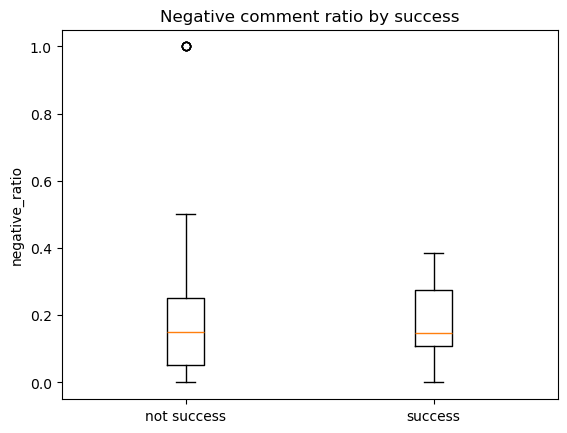

In [19]:
neg0 = df[df["success"] == 0]["negative_ratio"]
neg1 = df[df["success"] == 1]["negative_ratio"]

plt.figure()
plt.boxplot([neg0, neg1], labels=["not success", "success"])
plt.title("Negative comment ratio by success")
plt.ylabel("negative_ratio")
plt.show()


### Do Positive comments lead to success?

As well as above there is no coorelation to be found. 
The not success plot is more scattered but as before this might be due to a higher quantity of movies

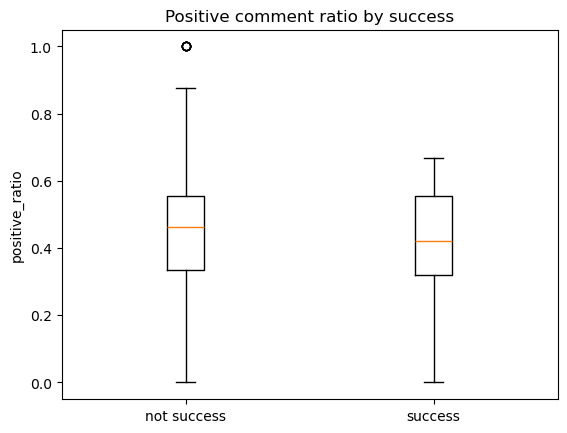

In [20]:
pos0 = df[df["success"] == 0]["positive_ratio"]
pos1 = df[df["success"] == 1]["positive_ratio"]

plt.figure()
plt.boxplot([pos0, pos1], labels=["not success", "success"])
plt.title("Positive comment ratio by success")
plt.ylabel("positive_ratio")
plt.show()


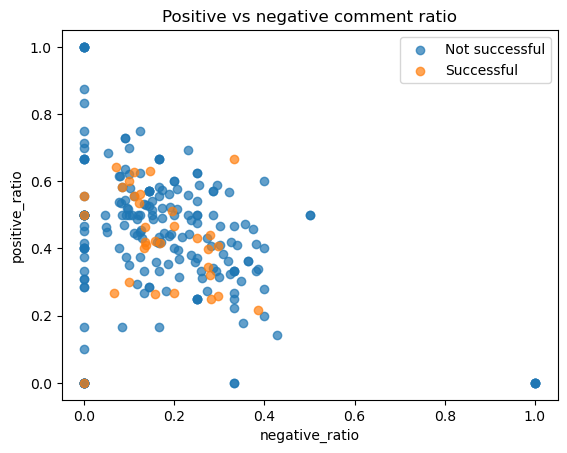

In [21]:
plt.figure()

# not successful
df0 = df[df["success"] == 0]
plt.scatter(
    df0["negative_ratio"],
    df0["positive_ratio"],
    label="Not successful",
    alpha=0.7
)

# successful
df1 = df[df["success"] == 1]
plt.scatter(
    df1["negative_ratio"],
    df1["positive_ratio"],
    label="Successful",
    alpha=0.7
)

plt.xlabel("negative_ratio")
plt.ylabel("positive_ratio")
plt.title("Positive vs negative comment ratio")
plt.legend()
plt.show()


### Is there a correlation between sentiment and rating?

As seen below successful movies have a higher rating but the sentiment is vastly similar.
There are a few outliner with unsuccessful movies which doesn't happen with successful movies.
It might be due to lower quantity of successful movies but one can say that based of the plot below, 
that a bad sentiment is an indicator for an unsuccessful movie.

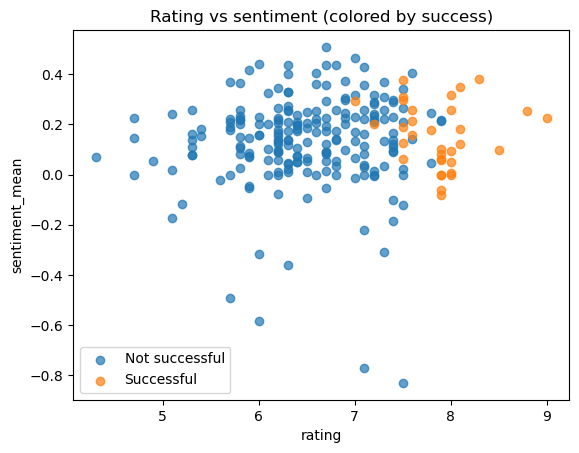

In [22]:
plt.figure()

# not successful
df0 = df[df["success"] == 0]
plt.scatter(
    df0["rating"],
    df0["sentiment_mean"],
    label="Not successful",
    alpha=0.7
)

# successful
df1 = df[df["success"] == 1]
plt.scatter(
    df1["rating"],
    df1["sentiment_mean"],
    label="Successful",
    alpha=0.7
)

plt.xlabel("rating")
plt.ylabel("sentiment_mean")
plt.title("Rating vs sentiment (colored by success)")
plt.legend()
plt.show()


### Spark ML

Lastly we tried to train a model in an attempt to predict the success of movies

In [23]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator


In [24]:
spark = SparkSession.builder \
    .appName("MovieSentimentSparkML") \
    .getOrCreate()

print("Spark session started")


Spark session started


In [25]:
sdf = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("../data/final_analysis_dataset.csv")

sdf.printSchema()
sdf.show(5)


root
 |-- video_id: string (nullable = true)
 |-- comment_count: integer (nullable = true)
 |-- sentiment_mean: double (nullable = true)
 |-- sentiment_median: double (nullable = true)
 |-- sentiment_std: double (nullable = true)
 |-- positive_ratio: double (nullable = true)
 |-- negative_ratio: double (nullable = true)
 |-- rating: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- success: integer (nullable = true)

+-----------+-------------+-------------------+----------------+-------------------+------------------+-------------------+------+-------+-------+
|   video_id|comment_count|     sentiment_mean|sentiment_median|      sentiment_std|    positive_ratio|     negative_ratio|rating|revenue|success|
+-----------+-------------+-------------------+----------------+-------------------+------------------+-------------------+------+-------+-------+
|-GQjm4TrQIM|           40|            0.16791|             0.0|0.36933602433528584|              0.45|              0.

In [26]:
sdf = sdf.withColumn(
    "sentiment_std",
    when(col("sentiment_std").isNull(), 0)
    .otherwise(col("sentiment_std"))
)


In [27]:
features = [
    "comment_count",
    "sentiment_mean",
    "sentiment_std",
    "positive_ratio",
    "negative_ratio",
]


In [28]:
assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

sdf_features = assembler.transform(sdf)


In [29]:
train_df, test_df = sdf_features.randomSplit([0.75, 0.25], seed=42)


In [30]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

scaler_model = scaler.fit(train_df)

train_scaled = scaler_model.transform(train_df)
test_scaled = scaler_model.transform(test_df)


In [31]:
lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="success",
    maxIter=2000
)

lr_model = lr.fit(train_scaled)


In [32]:
print("Intercept:", lr_model.intercept)
print("Coefficients:", lr_model.coefficients)


Intercept: -1.6650382455595119
Coefficients: [0.041204529438027625,0.7474383234793991,0.3563717251736667,-0.8177624027439193,0.009081333224373106]


In [33]:
predictions = lr_model.transform(test_scaled)

predictions.select(
    "success",
    "probability",
    "prediction"
).show(5)


+-------+--------------------+----------+
|success|         probability|prediction|
+-------+--------------------+----------+
|      0|[0.84059547372908...|       0.0|
|      0|[0.84075438547133...|       0.0|
|      0|[0.72407310560612...|       0.0|
|      1|[0.90524135925630...|       0.0|
|      1|[0.78993899339064...|       0.0|
+-------+--------------------+----------+
only showing top 5 rows



In [34]:
evaluator = BinaryClassificationEvaluator(
    labelCol="success",
    metricName="areaUnderROC"
)

roc_auc = evaluator.evaluate(predictions)
print("Spark ROC AUC:", roc_auc)


Spark ROC AUC: 0.5674603174603174


In [35]:
predictions.groupBy("success", "prediction").count().show()


+-------+----------+-----+
|success|prediction|count|
+-------+----------+-----+
|      1|       0.0|    6|
|      0|       0.0|   42|
+-------+----------+-----+



In [36]:
spark.stop()
print("Spark session stopped")


Spark session stopped
